In [2]:
!pip3 install numpy scikit-learn matplotlib seaborn dwave-ocean-sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 10.9 MB/s  0:00:001.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.3/581.3 kB 28.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.6/711.6 kB 25.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 988.4/988.4 kB 26.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 10.9 MB/s  0:00:011.1 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 27.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31/31 [dwave-ocean-sdk]32m25/31 [authlib]aphy]optimization]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 用于演示QUBO求解 (如果安装了dwave-ocean-sdk)
try:
    from neal import SimulatedAnnealingSampler
    HAS_DWAVE = True
except ImportError:
    HAS_DWAVE = False
    print("提示: 未检测到 'dwave-ocean-sdk'。将使用自定义的模拟退火求解器。")

提示: 未检测到 'dwave-ocean-sdk'。将使用自定义的模拟退火求解器。


In [4]:
def generate_synthetic_data(n_samples=5000, n_features=50, n_informative=5, noise=0.1):
    """生成具有非线性关系的模拟数据"""
    np.random.seed(42)
    # 1. 生成相关特征
    B = np.random.normal(0, 1, (n_features, n_features))
    C = B.T @ B
    X = np.random.multivariate_normal(np.zeros(n_features), C, n_samples)
    
    # 2. 定义源特征 (真正影响目标变量的特征)
    source_idx = [5, 11, 7, 1, 14]  # 论文中使用的索引 (注意Python从0开始)
    X = np.abs(X)  # 使数据为正，模拟基因表达数据
    
    # 3. 构建高度非线性的目标变量
    y = np.zeros(n_samples)
    for idx in source_idx:
        x_col = X[:, idx]
        # 使用论文中的非线性函数
        term = 0.5 * np.cos(7 * x_col) + np.sin(x_col * x_col) + \
               0.1 * np.exp(x_col) * np.log2(np.abs(10 * x_col) + 1e-6)
        y += term
    y = y / len(source_idx)  # 取平均
    
    # 4. 添加噪声
    y += noise * np.random.normal(0, 1, n_samples)
    y = (y - np.min(y)) / (np.max(y) - np.min(y))  # 归一化到 [0,1]
    
    # 5. 标准化特征
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y, source_idx

X, y, true_features = generate_synthetic_data(n_samples=5000, n_features=50)
print(f"模拟数据形状: X={X.shape}, y={y.shape}")
print(f"真实的源特征索引: {true_features}")

模拟数据形状: X=(5000, 50), y=(5000,)
真实的源特征索引: [5, 11, 7, 1, 14]


In [5]:
def compute_mutual_information_matrix(X, y, n_bins=10):
    """
    计算论文中定义的 I (特征-目标互信息) 和 R (特征-特征互信息)
    使用分箱离散化方法
    """
    n_features = X.shape[1]
    
    # 1. 对特征进行离散化 (分箱)
    # 使用分位数分箱，确保每个箱中数据点大致相等
    discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
    X_discrete = discretizer.fit_transform(X).astype(int)
    
    # 对目标变量进行离散化
    y_discrete = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile').fit_transform(y.reshape(-1, 1)).astype(int).flatten()
    
    # 2. 计算重要性 I (特征与目标变量的互信息)
    # 使用scikit-learn的实现，但为了与论文保持一致，我们基于离散化数据手动计算
    I = np.zeros(n_features)
    for i in range(n_features):
        # 计算离散互信息
        I[i] = mutual_info_regression(X[:, i].reshape(-1, 1), y, n_neighbors=3)[0]
    
    # 3. 计算冗余度 R (特征与特征之间的互信息)
    R = np.zeros((n_features, n_features))
    for i in range(n_features):
        for j in range(i+1, n_features):
            # 计算两个特征间的互信息
            mi = mutual_info_regression(X[:, i].reshape(-1, 1), X[:, j], n_neighbors=3)[0]
            R[i, j] = mi
            R[j, i] = mi  # 对称矩阵
            
    # 4. 设置R的对角线为0 (特征自身不冗余)
    np.fill_diagonal(R, 0)
    
    return I, R

# 计算I和R
I, R = compute_mutual_information_matrix(X, y)
print(f"重要性 I (前5个值): {I[:5]}")
print(f"冗余度 R (前5x5矩阵):\n{R[:5, :5]}")


重要性 I (前5个值): [0.         0.02879686 0.         0.         0.00161266]
冗余度 R (前5x5矩阵):
[[0.         0.00106134 0.0169062  0.         0.        ]
 [0.00106134 0.         0.00428792 0.00947581 0.        ]
 [0.0169062  0.00428792 0.         0.         0.        ]
 [0.         0.00947581 0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


In [7]:
def build_qubo_matrix(I, R, alpha=0.5):
    """
    根据论文公式 Qij(α) = Rij - α*(Rij - δij*Ii) 构建QUBO矩阵
    """
    n_features = len(I)
    Q = np.zeros((n_features, n_features))
    for i in range(n_features):
        for j in range(n_features):
            delta = 1.0 if i == j else 0.0
            # 注意: 论文中的公式 Qij = Rij - α*(Rij - δij*Ii)
            Q[i, j] = R[i, j] - alpha * (R[i, j] - delta * I[i])
    return Q
    
# 构建QUBO矩阵
alpha = 0.6  # 平衡参数，可以从0到1调整
Q = build_qubo_matrix(I, R, alpha)
print(f"QUBO矩阵形状: {Q.shape}")
print(f"QUBO矩阵 (前5x5):\n{Q[:5, :5]}")

QUBO矩阵形状: (50, 50)
QUBO矩阵 (前5x5):
[[0.         0.00042454 0.00676248 0.         0.        ]
 [0.00042454 0.01727812 0.00171517 0.00379032 0.        ]
 [0.00676248 0.00171517 0.         0.         0.        ]
 [0.         0.00379032 0.         0.         0.        ]
 [0.         0.         0.         0.         0.00096759]]


In [8]:
# 方式 A: 如果安装了D-Wave库，使用模拟退火求解器
# 方式 B: 使用自定义的简单模拟退火

def custom_simulated_annealing(Q, num_selected=20, max_iter=10000, temp_init=10.0, temp_min=0.1, cooling_rate=0.99):
    """
    一个简单的模拟退火实现，用于求解QUBO特征选择问题。
    直接基于论文中的目标函数: E(F) = F^T * Q * F
    选择固定数量的特征 (num_selected)
    """
    n = Q.shape[0]
    # 初始解: 随机选择 num_selected 个特征
    current = np.zeros(n, dtype=int)
    indices = np.random.choice(n, num_selected, replace=False)
    current[indices] = 1
    
    # 计算能量
    def energy(f):
        return f @ Q @ f
    
    current_energy = energy(current)
    best = current.copy()
    best_energy = current_energy
    
    temp = temp_init
    iter_count = 0
    accept_count = 0
    
    while temp > temp_min and iter_count < max_iter:
        # 生成邻域解: 交换一个选中的特征和一个未选中的特征
        ones = np.where(current == 1)[0]
        zeros = np.where(current == 0)[0]
        if len(ones) == 0 or len(zeros) == 0:
            break
            
        idx1 = np.random.choice(ones)
        idx0 = np.random.choice(zeros)
        
        # 创建新解
        new = current.copy()
        new[idx1] = 0
        new[idx0] = 1
        new_energy = energy(new)
        
        # 接受准则 (Metropolis)
        delta_E = new_energy - current_energy
        if delta_E < 0 or np.random.random() < np.exp(-delta_E / max(temp, 1e-6)):
            current = new
            current_energy = new_energy
            accept_count += 1
            if current_energy < best_energy:
                best = current.copy()
                best_energy = current_energy
        
        temp *= cooling_rate
        iter_count += 1
        
        if iter_count % 1000 == 0:
            print(f"Iter {iter_count}, Temp: {temp:.4f}, Best Energy: {best_energy:.4f}")
    
    print(f"模拟退火完成, 共接受 {accept_count} 次, 最佳能量: {best_energy:.4f}")
    return best

# 选择要选出的特征数量 K (论文中通常使用50)
K = 20
print("使用自定义模拟退火求解QUBO...")
selected_features_qubo = custom_simulated_annealing(Q, num_selected=K, max_iter=8000, temp_init=5.0, cooling_rate=0.995)
selected_idx_qubo = np.where(selected_features_qubo == 1)[0]
print(f"QUBO选出的 {len(selected_idx_qubo)} 个特征索引: {selected_idx_qubo}")


使用自定义模拟退火求解QUBO...
模拟退火完成, 共接受 765 次, 最佳能量: 0.5886
QUBO选出的 20 个特征索引: [ 0  6  9 11 12 14 18 19 20 23 25 27 30 31 34 39 40 42 45 46]



=== 特征选择结果比较 (K=20) ===
真实特征索引:         [5, 11, 7, 1, 14]
QUBO选中的特征:       [np.int64(0), np.int64(6), np.int64(9), np.int64(11), np.int64(12), np.int64(14), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(25), np.int64(27), np.int64(30), np.int64(31), np.int64(34), np.int64(39), np.int64(40), np.int64(42), np.int64(45), np.int64(46)]
LASSO选中的特征:      [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(48), np.int64(49)]
随机森林选中的特征:   [np.int64(0), np.int64(1), np.int64(5), np.int64(7), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(18), np.int64(22), np.int64(23), np.int64(27), np.int64(29), np.int64(30), np.int64(37), np.int64(38), np.int64(45), np.int64(46), np.int64(49)]

召回率 (Recall):
  QUBO:       40.00%
  LASSO:      80.00%
  随机森林

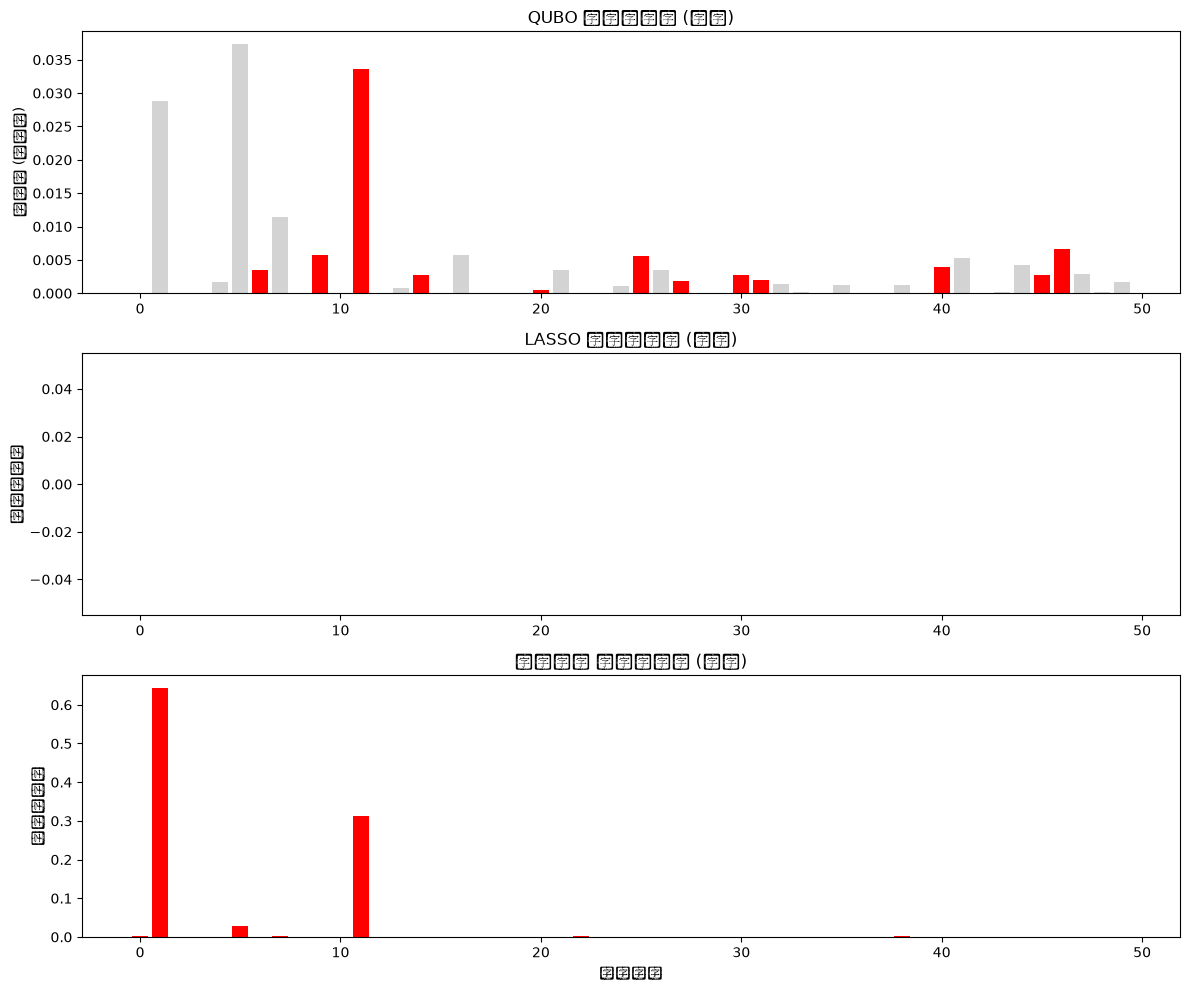

In [9]:
def compare_with_lasso_rfr(X, y, true_features, selected_idx_qubo, K=20):
    """比较QUBO、LASSO和随机森林的特征选择结果"""
    
    # 1. LASSO特征选择
    lasso = Lasso(alpha=0.01, max_iter=10000)
    lasso.fit(X, y)
    lasso_coef = np.abs(lasso.coef_)
    selected_idx_lasso = np.argsort(lasso_coef)[-K:]  # 取系数最大的K个特征
    
    # 2. 随机森林特征选择
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)
    rf_importance = rf.feature_importances_
    selected_idx_rf = np.argsort(rf_importance)[-K:]
    
    # 3. 计算准确率 (识别出真实特征的比例)
    def recall_at_k(selected_idx):
        return len(set(selected_idx) & set(true_features)) / len(true_features)
    
    print(f"\n=== 特征选择结果比较 (K={K}) ===")
    print(f"真实特征索引:         {true_features}")
    print(f"QUBO选中的特征:       {sorted(selected_idx_qubo)}")
    print(f"LASSO选中的特征:      {sorted(selected_idx_lasso)}")
    print(f"随机森林选中的特征:   {sorted(selected_idx_rf)}")
    
    print(f"\n召回率 (Recall):")
    print(f"  QUBO:       {recall_at_k(selected_idx_qubo):.2%}")
    print(f"  LASSO:      {recall_at_k(selected_idx_lasso):.2%}")
    print(f"  随机森林:   {recall_at_k(selected_idx_rf):.2%}")
    
    # 4. 可视化：特征重要性与选择情况
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # 绘制QUBO选择的特征
    ax = axes[0]
    importance_qubo = np.array([I[i] for i in range(len(I))])
    colors = ['red' if i in selected_idx_qubo else 'lightgray' for i in range(len(importance_qubo))]
    ax.bar(range(len(importance_qubo)), importance_qubo, color=colors)
    ax.set_title('QUBO 选择的特征 (红色)')
    ax.set_ylabel('重要性 (互信息)')
    
    # 绘制LASSO选择的特征
    ax = axes[1]
    colors = ['red' if i in selected_idx_lasso else 'lightgray' for i in range(len(lasso_coef))]
    ax.bar(range(len(lasso_coef)), lasso_coef, color=colors)
    ax.set_title('LASSO 选择的特征 (红色)')
    ax.set_ylabel('系数绝对值')
    
    # 绘制随机森林选择的特征
    ax = axes[2]
    colors = ['red' if i in selected_idx_rf else 'lightgray' for i in range(len(rf_importance))]
    ax.bar(range(len(rf_importance)), rf_importance, color=colors)
    ax.set_title('随机森林 选择的特征 (红色)')
    ax.set_xlabel('特征索引')
    ax.set_ylabel('特征重要性')
    
    plt.tight_layout()
    plt.show()
    
    return selected_idx_lasso, selected_idx_rf

# 运行对比
selected_idx_lasso, selected_idx_rf = compare_with_lasso_rfr(X, y, true_features, selected_idx_qubo, K)


In [11]:
def evaluate_selected_features(X, y, selected_indices):
    """使用选出的特征进行回归，评估预测性能"""
    X_selected = X[:, selected_indices]
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)
    
    # 使用简单的线性回归
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

print("评估不同特征子集的回归性能 (MSE):")
print(f"  使用QUBO选择的特征 (K={len(selected_idx_qubo)}): {evaluate_selected_features(X, y, selected_idx_qubo):.4f}")
print(f"  使用LASSO选择的特征 (K={len(selected_idx_lasso)}): {evaluate_selected_features(X, y, selected_idx_lasso):.4f}")
print(f"  使用随机森林选择的特征 (K={len(selected_idx_rf)}): {evaluate_selected_features(X, y, selected_idx_rf):.4f}")
print(f"  使用所有特征: {evaluate_selected_features(X, y, list(range(X.shape[1]))):.4f}")



import numpy as np

def qubo_to_ising(Q):
    """
    将QUBO矩阵 Q (n x n) 转换为伊辛模型参数 h (n) 和 J (n x n)。
    
    参数:
        Q: n x n 的QUBO矩阵 (可以是上三角或对称矩阵)
        
    返回:
        h: 长度为n的数组，代表外磁场项
        J: n x n 的对称矩阵，代表耦合项 (对角线为0)
    """
    n = Q.shape[0]
    # 确保Q是对称矩阵 (如果输入是上三角，则对称化)
    Q_sym = (Q + Q.T) / 2
    
    # 初始化 h 和 J
    h = np.zeros(n)
    J = np.zeros((n, n))
    
    # 1. 计算外磁场项 h
    for i in range(n):
        # 公式: h_i = - Q_ii / 2 - (1/4) * sum_{k != i} Q_ik
        sum_off_diag = np.sum(Q_sym[i, :]) - Q_sym[i, i]  # 减去对角线
        h[i] = -Q_sym[i, i] / 2 - (1/4) * sum_off_diag
        
    # 2. 计算耦合项 J
    for i in range(n):
        for j in range(i+1, n):
            # 公式: J_ij = - Q_ij / 4
            J[i, j] = -Q_sym[i, j] / 4
            J[j, i] = J[i, j]  # 对称
    
    return h, J

# --- 使用示例 (基于你之前的QUBO矩阵) ---
# 假设你已经有了一个QUBO矩阵 Q (比如之前构建的 Q)
h, J = qubo_to_ising(Q)
print("转换后的外磁场 h:", h)
print("转换后的耦合矩阵 J:\n", J)

# --- 验证转换是否正确 (可选) ---
def verify_conversion(Q, h, J, num_samples=10):
    """
    验证对于随机自旋配置，伊辛模型的能量与QUBO模型的能量差是否为常数。
    """
    n = Q.shape[0]
    for _ in range(num_samples):
        # 随机生成一个自旋配置 s ∈ {-1, 1}
        s = np.random.choice([-1, 1], n)
        # 转换为对应的二进制 x ∈ {0, 1}
        x = (s + 1) / 2
        
        # 计算QUBO能量
        E_qubo = x @ Q @ x
        
        # 计算伊辛能量 (忽略常数项)
        E_ising = - np.sum(h * s) - np.sum(J * s[:, None] * s[None, :]) / 2  # 除以2避免重复计算
        
        # 计算能量差
        diff = E_qubo - E_ising
        print(f"QUBO能量: {E_qubo:.4f}, Ising能量: {E_ising:.4f}, 差值: {diff:.4f}")

# 如果你的Q矩阵已经定义，可以取消注释下面的行来运行验证
if 'Q' in locals():
    h, J = qubo_to_ising(Q)
    verify_conversion(Q, h, J)

评估不同特征子集的回归性能 (MSE):
  使用QUBO选择的特征 (K=20): 0.0002
  使用LASSO选择的特征 (K=20): 0.0002
  使用随机森林选择的特征 (K=20): 0.0002
  使用所有特征: 0.0002
转换后的外磁场 h: [-0.01650207 -0.03387285 -0.02179946 -0.02413736 -0.02286633 -0.03318571
 -0.02510603 -0.02868192 -0.02733277 -0.0284296  -0.02441963 -0.03825835
 -0.02709799 -0.02611484 -0.02870302 -0.02373377 -0.02645224 -0.02813546
 -0.02484468 -0.01479615 -0.0218736  -0.02939026 -0.0240396  -0.01799226
 -0.03592499 -0.02418439 -0.01989968 -0.01157272 -0.02879873 -0.02456562
 -0.01917148 -0.01884868 -0.02986304 -0.02276563 -0.03008788 -0.02526998
 -0.02550411 -0.02661914 -0.02229511 -0.02046014 -0.02497147 -0.02377925
 -0.02041277 -0.02493675 -0.02290837 -0.02631823 -0.01733349 -0.02416138
 -0.02515112 -0.02166789]
转换后的耦合矩阵 J:
 [[ 0.         -0.00010613 -0.00169062 ... -0.00163903 -0.00237977
  -0.        ]
 [-0.00010613  0.         -0.00042879 ... -0.         -0.
  -0.00107787]
 [-0.00169062 -0.00042879  0.         ... -0.         -0.
  -0.00100883]
 ...
 [-0.001